# 04. DDPM Results
Visualize DDIM samples, training loss curve, and compute FID.

In [1]:
import sys; sys.path.insert(0, '..')

import torch
import yaml
from IPython.display import Image as IPImage

from src.models.ddpm import GaussianDiffusion, UNet, EMA
from src.utils.seed import set_seed
from src.utils.visualization import save_image_grid
from src.evaluation.fid import save_samples, compute_fid

set_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

with open('../configs/ddpm_config.yaml', encoding='utf-8') as f:
    cfg = yaml.safe_load(f)
mc, dc, sc = cfg['model'], cfg['diffusion'], cfg['sampling']

Device: cuda


In [2]:
CKPT = '../checkpoints/ddpm/ddpm_epoch0200.pt'
model = UNet(
    image_channels=mc['image_channels'], base_channels=mc['base_channels'],
    channel_mults=tuple(mc['channel_mults']),
    attention_resolutions=tuple(mc['attention_resolutions']),
    num_res_blocks=mc['num_res_blocks'], dropout=mc['dropout']
).to(device)
state = torch.load(CKPT, map_location=device)
# apply EMA weights stored in checkpoint
for name, param in model.named_parameters():
    if name in state['ema_shadow']:
        param.data.copy_(state['ema_shadow'][name])
model.eval()
print(f"Loaded checkpoint from epoch {state['epoch']}")

Loaded checkpoint from epoch 200


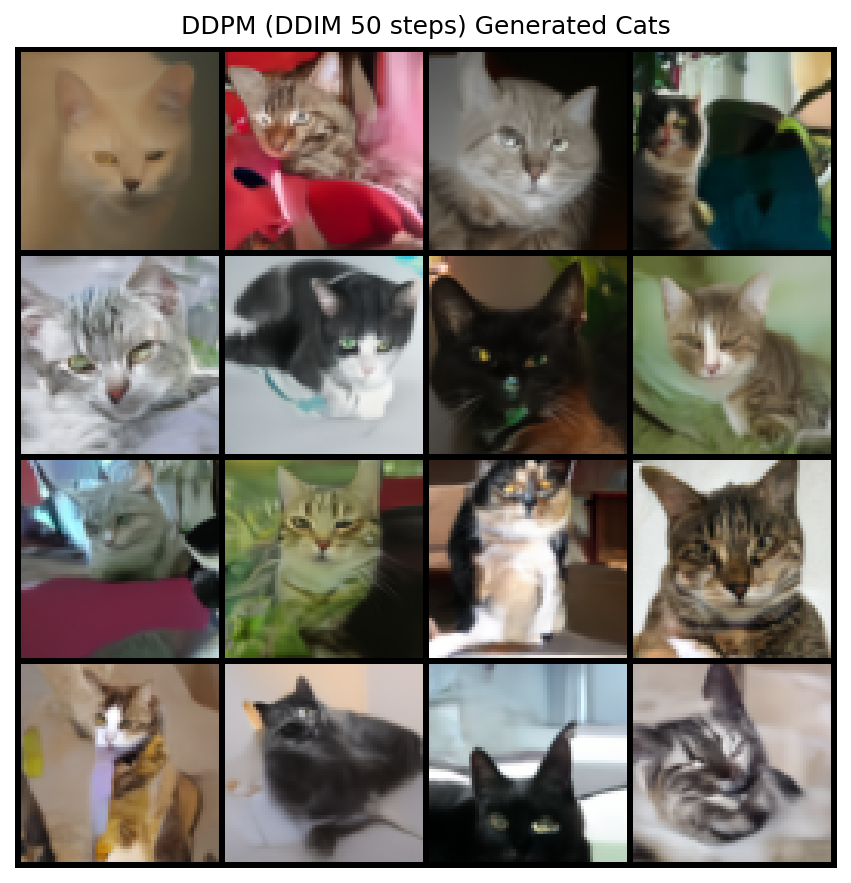

In [3]:
diffusion = GaussianDiffusion(
    timesteps=dc['timesteps'], beta_start=dc['beta_start'],
    beta_end=dc['beta_end'], schedule=dc['schedule'], device=device
)
img_size = cfg['data']['image_size']
with torch.no_grad():
    samples = diffusion.ddim_sample(
        model, (16, mc['image_channels'], img_size, img_size),
        ddim_steps=sc['ddim_steps'], eta=sc['eta']
    )
save_image_grid(samples, '../outputs/ddpm/notebook_samples.png', nrow=4,
                title=f'DDPM (DDIM {sc["ddim_steps"]} steps) Generated Cats')
IPImage('../outputs/ddpm/notebook_samples.png')

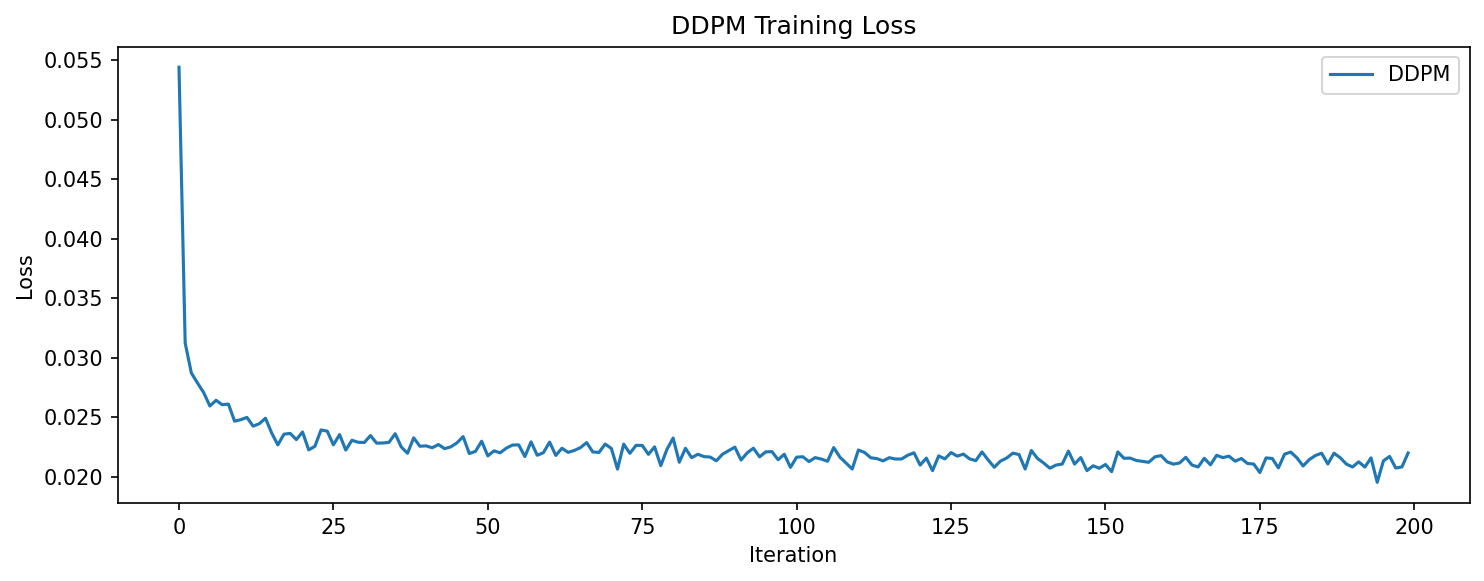

In [4]:
IPImage('../outputs/ddpm/losses.png')

In [5]:
save_samples(
    model, '../outputs/ddpm/fid_samples',
    n_samples=5000, batch_size=16, device=device,
    diffusion=diffusion,
    sample_shape=(16, mc['image_channels'], img_size, img_size),
    ddim_steps=sc['ddim_steps'], eta=sc['eta']
)
fid = compute_fid('../outputs/real_64', '../outputs/ddpm/fid_samples')
print(f'DDPM FID: {fid:.2f}')

Saved 5000 images to ..\outputs\ddpm\fid_samples
DDPM FID: 24.36


In [6]:
import json
import pandas as pd

with open('../outputs/ablation/ddpm_steps_results.json') as f:
    steps_data = json.load(f)

rows = [
    {'DDIM Steps': v['ddim_steps'], 'FID': round(v['fid'], 2),
     'Speedup vs 1000-step': f"{1000 // v['ddim_steps']}x"}
    for v in sorted(steps_data.values(), key=lambda x: x['ddim_steps'])
]
df_steps = pd.DataFrame(rows)
print("DDPM: FID vs DDIM inference steps (epoch-200 checkpoint, non-EMA, 5000 samples)")
print(df_steps.to_markdown(index=False))

DDPM: FID vs DDIM inference steps (epoch-200 checkpoint, non-EMA, 5000 samples)
|   DDIM Steps |   FID | Speedup vs 1000-step   |
|-------------:|------:|:-----------------------|
|           10 | 66.92 | 100x                   |
|           25 | 60.02 | 40x                    |
|           50 | 54.51 | 20x                    |
|          100 | 48.7  | 10x                    |
|          200 | 39.81 | 5x                     |


In [7]:
import pandas as pd

# ablation above uses raw (non-EMA) weights; applying EMA at the same 50 steps gives FID=24.36
ema_comparison = [
    {'Weights': 'without EMA', 'DDIM Steps': 50, 'FID': 54.51},
    {'Weights': 'with EMA',    'DDIM Steps': 50, 'FID': 24.36},
]
df_ema = pd.DataFrame(ema_comparison)
print("EMA effect at 50 DDIM steps:")
print(df_ema.to_markdown(index=False))
improvement = (54.51 - 24.36) / 54.51 * 100
print(f"\nEMA reduces FID by {54.51-24.36:.2f} points ({improvement:.0f}%)")

EMA effect at 50 DDIM steps:
| Weights     |   DDIM Steps |   FID |
|:------------|-------------:|------:|
| without EMA |           50 | 54.51 |
| with EMA    |           50 | 24.36 |

EMA reduces FID by 30.15 points (55%)
